In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sqlalchemy import create_engine
from dotenv import load_dotenv
load_dotenv()
DATABASE_URL = (
    f"postgresql://{os.getenv('DB_USERNAME')}:"
    f"{os.getenv('DB_PASSWORD')}@"
    f"{os.getenv('DB_HOST')}:"
    f"{os.getenv('DB_PORT')}/"
    f"{os.getenv('DB_NAME')}"
)
engine = create_engine(DATABASE_URL)

               artist_Name  total_Revenue
0              The Trooper          49.50
1                 Eruption          45.54
2           The Woman King          43.77
3                Walkabout          43.77
4                  The Fix          43.77
5                 Untitled          37.62
6  The Number Of The Beast          34.65
7      Sure Know Something          32.67
8        Where Eagles Dare          31.68
9        Phyllis's Wedding          29.82


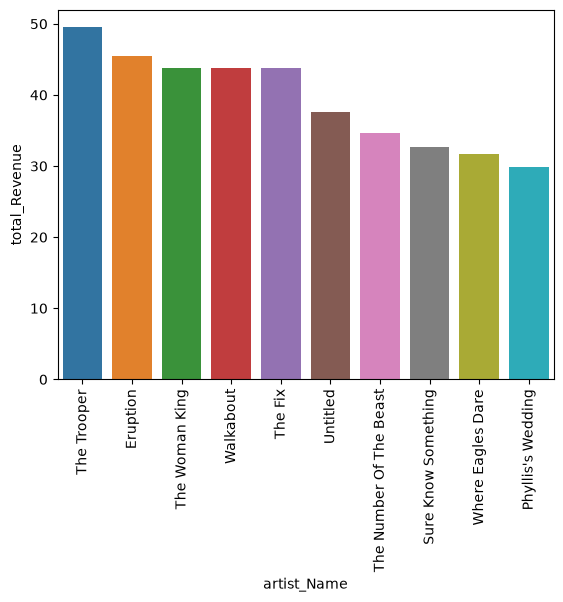

In [7]:
# Top 10 artists by revenue
top_10_revenue_artist_query = pd.read_sql_query(
                                 """
                                    select t."name" as "artist_Name",sum(i.total) as "total_Revenue"
                                        from track t
                                    join invoice_line il  
                                        on t.track_id =il.track_id
                                    join invoice i 
                                        on i.invoice_id = il.invoice_id 
                                    join album a 
                                        on a.album_id =t.album_id 
                                    join artist a2 
                                        on a2.artist_id = a.artist_id 
                                    group by "artist_Name" 
                                    order by "total_Revenue" desc 
                                    limit 10;
                                        """
                                    ,engine)
print(top_10_revenue_artist_query)
sns.barplot(
    data=top_10_revenue_artist_query,
    x="artist_Name" ,
    y="total_Revenue",
    hue="artist_Name"
)
plt.xticks(rotation = 90)
plt.show()

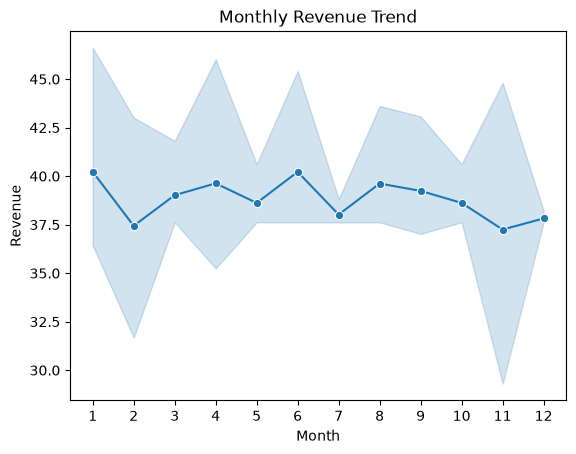

In [20]:
## Monthly revenue trend
month_revenue = pd.read_sql_query(
    """
    SELECT
        date_part('year', invoice_date)::int AS Year,
        date_part('month', invoice_date)::int AS Month,
        SUM(total) AS Revenue
    FROM invoice
    GROUP BY Year, Month
    ORDER BY Year, Month;
    """,
    engine
)
sns.lineplot(
    data=month_revenue,
    x="month",
    y="revenue",
    marker="o"
)

plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")
plt.show()

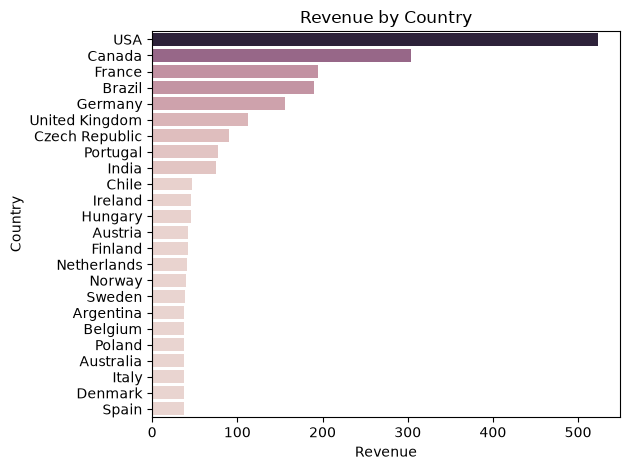

In [24]:
country_revenue = pd.read_sql_query(
    """
    SELECT
        c.country AS country,
        SUM(i.total) AS revenue
    FROM customer c
    INNER JOIN invoice i
        ON c.customer_id = i.customer_id
    GROUP BY country
    ORDER BY revenue DESC;
    """,
    engine
)
sns.barplot(
    data=country_revenue,
    x="revenue",
    y="country",
    hue="revenue",
    legend=False
)
plt.title("Revenue by Country")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()

plt.show()